<a href="https://colab.research.google.com/github/BagusWichaksono/PCVK_Ganjil_2026/blob/main/Modul2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modul 2 — D1. Pengenalan Python: Pengolahan Citra Dasar dan Memahami Channel Warna pada OpenCV dan Konversinya**

Pada bagian praktikum D1 ini, dipelajari mengenai:
1. Menghubungkan Google Colab dengan Google Drive.
2. Membaca citra digital dan menampilkan informasi resolusi/dimensi citra.
3. Memahami perbedaan format warna BGR (default OpenCV) dan RGB (Matplotlib).
4. Melakukan konversi ruang warna BGR ke RGB dan menampilkan hasilnya.
5. Membaca dan menampilkan citra keabuan (Grayscale) menggunakan berbagai colormap.
6. Operasi dasar pengubahan ukuran citra (*resizing*), pencerminan (*flipping*), dan penyesuaian ukuran kanvas (*canvas size*).

Langkah 1 — Mount Google Drive & Import Library

In [1]:
# 1. Menghubungkan Colab dengan Google Drive
from google.colab import drive

drive.mount('/content/drive')

# 2. Mengimpor library yang dibutuhkan
import os
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

print('Library berhasil diimpor dan Drive terhubung!')

Mounted at /content/drive
Library berhasil diimpor dan Drive terhubung!


Langkah 2 — Membaca dan Menampilkan Gambar dari Drive

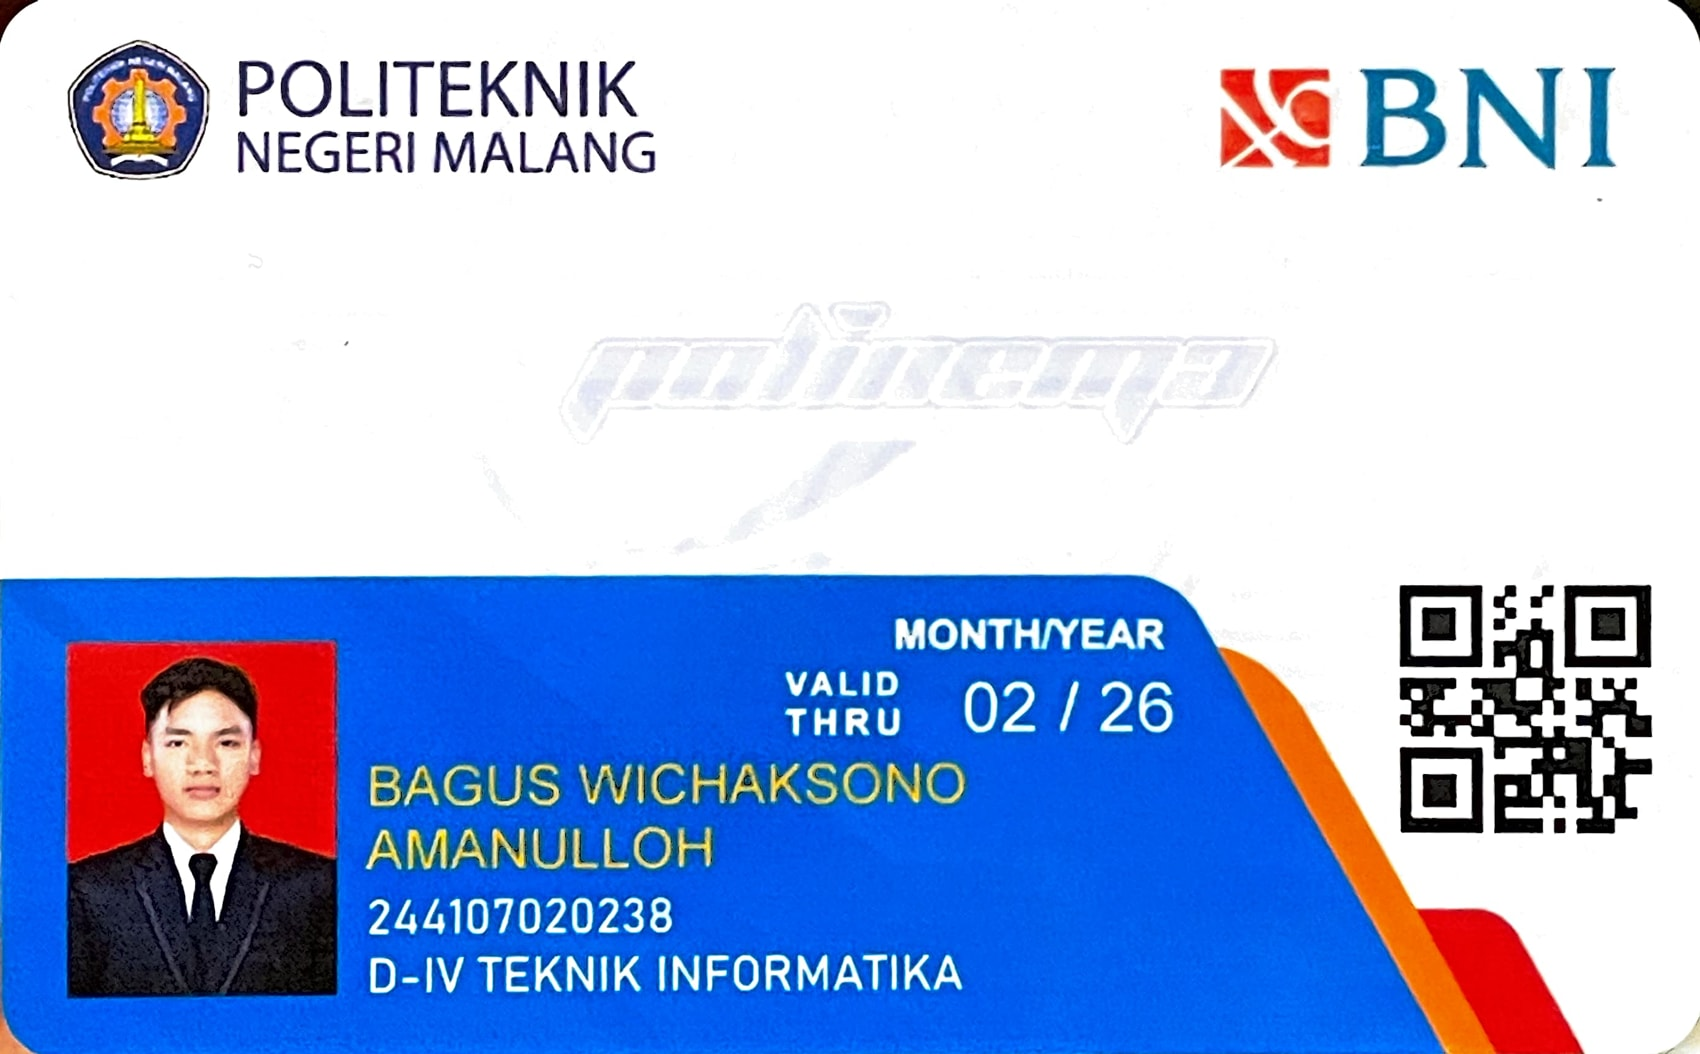

Resolusi gambar: 1700 x 1054
Jumlah channel warna: 3


In [2]:
# Path file gambar KTM/KTP di Drive
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'

# Membaca gambar menggunakan OpenCV
img = cv.imread(path_ktm)

if img is None:
  print(f'Error: File gambar tidak ditemukan pada path: {path_ktm}')
else:
  # Menampilkan gambar langsung di Colab dengan cv2_imshow (Format BGR)
  cv2_imshow(img)

  # Menampilkan resolusi gambar (Lebar x Tinggi)
  print(f'Resolusi gambar: {img.shape[1]} x {img.shape[0]}')
  print(f'Jumlah channel warna: {img.shape[2]}')

Langkah 3 — Memahami Format Warna BGR pada Matplotlib

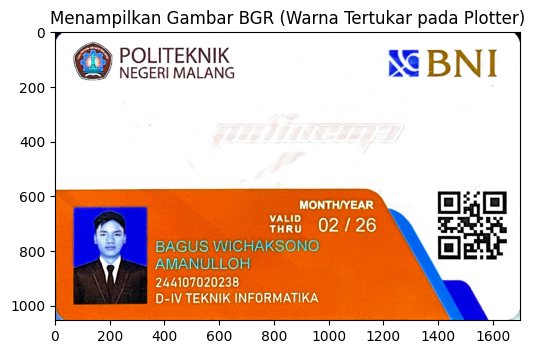

In [3]:
# Menampilkan gambar BGR langsung menggunakan Matplotlib (Warna akan tampak kebiruan)
plt.figure(figsize=(6, 4))
plt.imshow(img)  # Tanpa konversi, Matplotlib menganggap BGR sebagai RGB
plt.title('Menampilkan Gambar BGR (Warna Tertukar pada Plotter)')
plt.axis('on')
plt.show()

Langkah 4 — Konversi Channel Warna BGR ke RGB

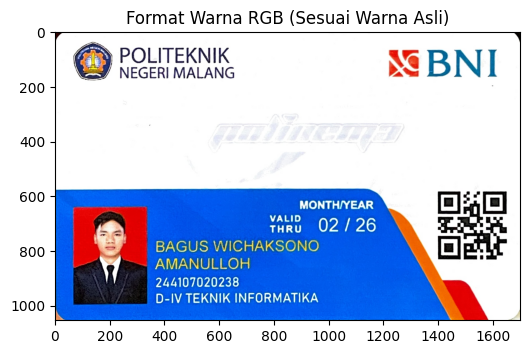

In [4]:
# Cara 1: Menggunakan cv.cvtColor
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Menampilkan hasil konversi dengan Matplotlib (Warna Asli)
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title('Format Warna RGB (Sesuai Warna Asli)')
plt.axis('on')
plt.show()

Langkah 5 — Membaca dan Menampilkan Citra Grayscale

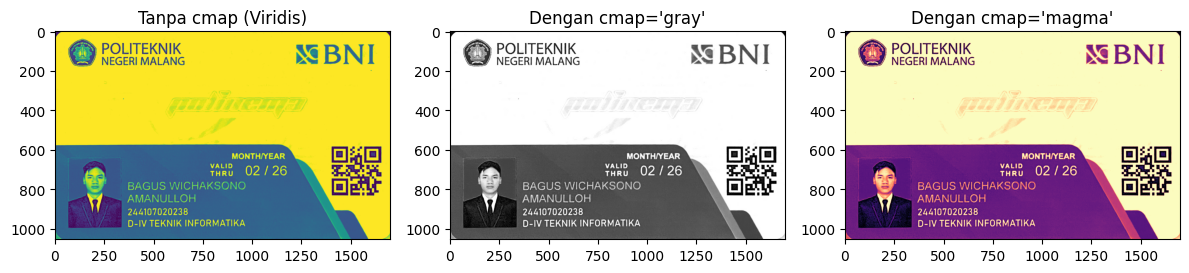

In [5]:
# Membaca citra secara langsung dalam format Grayscale
img_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 4))

# 1. Tanpa cmap (Colormap bawaan Matplotlib 'viridis')
plt.subplot(1, 3, 1)
plt.imshow(img_gray)
plt.title('Tanpa cmap (Viridis)')

# 2. Dengan cmap='gray' (Hitam-Putih Asli)
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Dengan cmap='gray'")

# 3. Dengan colormap 'magma' (Pseudocolor)
plt.subplot(1, 3, 3)
plt.imshow(img_gray, cmap='magma')
plt.title("Dengan cmap='magma'")

plt.tight_layout()
plt.show()

Langkah 6 — Resizing (Pengubahan Ukuran Citra)

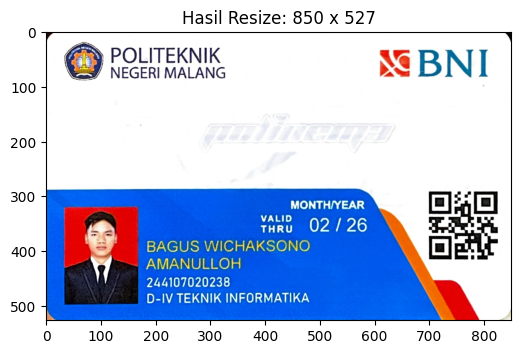

In [6]:
# Menghitung setengah dari ukuran asli
height, width = img.shape[:2]
new_width = width // 2
new_height = height // 2

# Konversi BGR ke RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Mengubah ukuran gambar
img_resized = cv.resize(img_rgb, (new_width, new_height))

# Menampilkan gambar hasil resize
plt.figure(figsize=(6, 4))
plt.imshow(img_resized)
plt.title(f'Hasil Resize: {new_width} x {new_height}')
plt.show()

Langkah 7 — Flipping (Pencerminan Gambar)

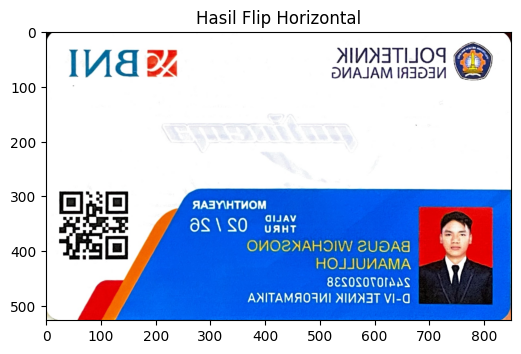

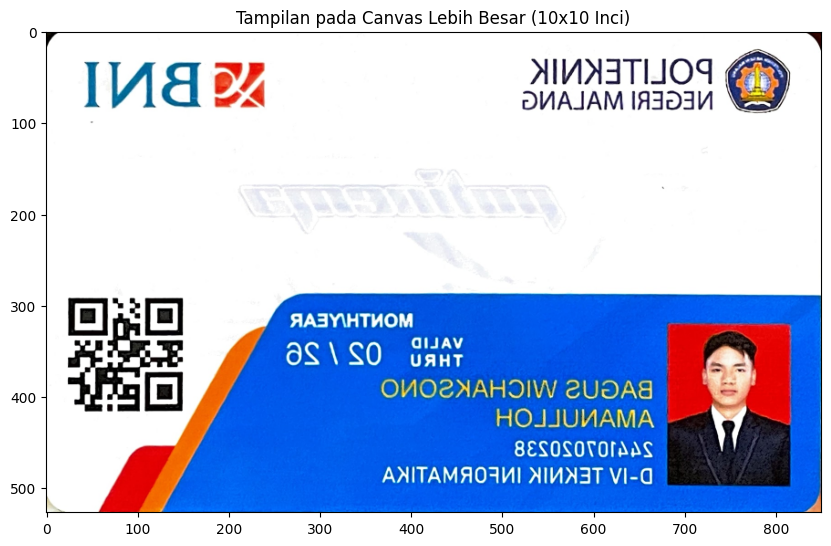

In [7]:
# Horizontal Flip (flipCode = 1)
img_flip = cv.flip(img_resized, 1)

# Menampilkan dengan canvas biasa
plt.figure(figsize=(6, 4))
plt.imshow(img_flip)
plt.title('Hasil Flip Horizontal')
plt.show()

# Menampilkan dengan ukuran canvas yang lebih besar (figsize=(10, 10))
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(img_flip)
ax.set_title('Tampilan pada Canvas Lebih Besar (10x10 Inci)')
plt.show()

### Menggambar Bentuk Geometri 2D dan Teks dengan OpenCV

Pada bagian ini dipelajari cara membuat kanvas kosong menggunakan NumPy (`np.zeros`) serta menggambar elemen geometri 2D (`cv.rectangle`, `cv.circle`, `cv.line`, `cv.putText`, dan `cv.polylines`).

1. Kanvas Hitam & Rectangle

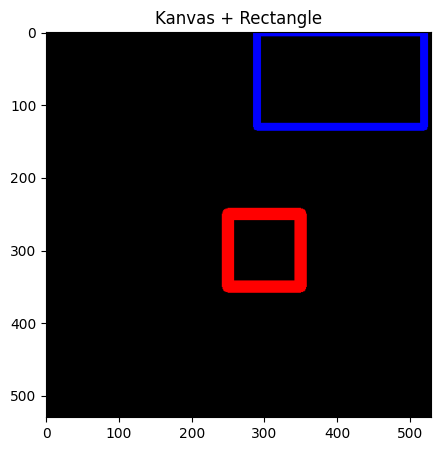

In [13]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Membuat kanvas hitam 530x530 piksel
black_img = np.zeros(shape=(530, 530, 3), dtype=np.uint8)

# 2. Menambahkan persegi panjang biru (pt1=(290,0), pt2=(520,130))
cv.rectangle(
    black_img, pt1=(290, 0), pt2=(520, 130), color=(0, 0, 255), thickness=10
)

# 3. Menambahkan persegi merah (pt1=(250,250), pt2=(350,350))
cv.rectangle(
    black_img, pt1=(250, 250), pt2=(350, 350), color=(255, 0, 0), thickness=15
)

# 4. Menampilkan hasil
plt.figure(figsize=(5, 5))
plt.imshow(black_img)
plt.title('Kanvas + Rectangle')
plt.show()

2. Tambah Circle, Line, & Text

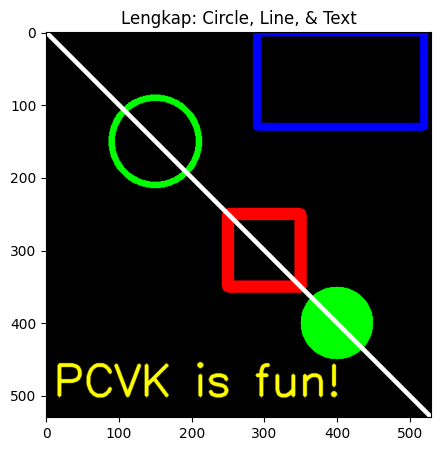

In [15]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Menambahkan lingkaran hijau berongga
cv.circle(
    black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8
)

# 2. Menambahkan lingkaran hijau solid (thickness=-1)
cv.circle(
    black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1
)

# 3. Menambahkan garis diagonal putih
cv.line(
    black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5
)

# 4. Menambahkan Teks "PCVK is fun!"
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(
    black_img,
    text='PCVK is fun!',
    org=(10, 500),
    fontFace=font,
    fontScale=2,
    color=(255, 255, 0),
    thickness=3,
    lineType=cv.LINE_AA,
)

# 5. Menampilkan hasil
plt.figure(figsize=(5, 5))
plt.imshow(black_img)
plt.title('Lengkap: Circle, Line, & Text')
plt.show()

3. Kanvas int32 & Polylines

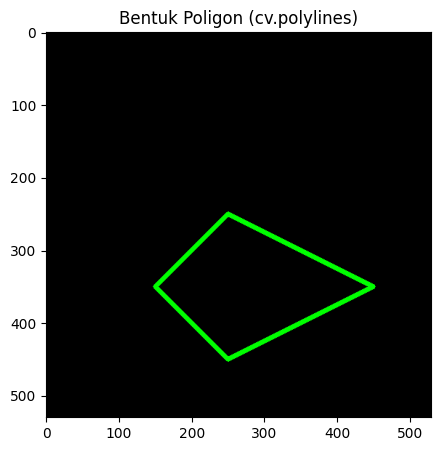

In [16]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Membuat kanvas hitam baru berukuran 530x530 (menggunakan uint8 agar bisa di-imshow tanpa error)
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.uint8)

# 2. Inisialisasi titik-titik sudut (vertices) bertipe int32 (syarat wajib cv.polylines)
vertices = np.array(
    [[150, 350], [250, 250], [450, 350], [250, 450]], dtype=np.int32
)

# 3. Reshape matriks ke bentuk (-1, 1, 2)
pts = vertices.reshape((-1, 1, 2))

# 4. Menggambar bentuk poligon tertutup (polylines) berwarna hijau
cv.polylines(
    black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5
)

# 5. Menampilkan hasil
plt.figure(figsize=(5, 5))
plt.imshow(black_img2)
plt.title('Bentuk Poligon (cv.polylines)')
plt.show()

## **Pertanyaan Praktikum Modul 2**

1. **Perbedaan `cv2_imshow()` dan `plt.imshow()`**:
   * `cv2_imshow()` mengasumsikan input berformat warna **BGR**.
   * `plt.imshow()` mengasumsikan input berformat warna **RGB**.
   * Jika gambar BGR dibaca OpenCV lalu ditampilkan langsung dengan Matplotlib tanpa konversi, warna akan tampak terbalik (merah jadi biru dan sebaliknya).

2. **Perbandingan Kanvas `int16` vs `int32`**:
   * **`dtype`**: `int16` berukuran 2 byte per elemen, sedangkan `int32` berukuran 4 byte per elemen.
   * **Ukuran Memori (`nbytes`)**: Memori `int32` tepat 2 kali lipat lebih besar dibanding `int16`.
   * **Tampilan Visual**: Keduanya tampak serba hitam karena seluruh elemen bernilai `0`.

3. **Alasan `cv2.imshow()` Tidak Dapat Dipakai di Colab**:
   * `cv2.imshow()` memerlukan jendela GUI lokal dari sistem operasi. Karena Google Colab berjalan di *cloud server* tanpa layar, fungsi tersebut akan error. Sebagai gantinya digunakan patch `cv2_imshow()` dari `google.colab.patches`.

4. **Pembuktian Warna `skimage` vs `cv2.cvtColor`**:
   * `skimage.io.imread()` membaca citra langsung dalam format **RGB**.
   * `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` mengonversi citra BGR dari OpenCV menjadi **RGB**.
   * Jika `cv2.cvtColor()` diterapkan lagi pada citra hasil `skimage`, kanalnya justru akan terbalik menjadi BGR.

5. **Pengaruh `figsize` Terhadap `img.shape`**:
   * Mengubah `figsize` hanya memperbesar/memperkecil kanvas tampilan visualisasi pada layar, tanpa mengubah matriks piksel.
   * Dimensi matriks piksel asli (`img.shape`) tidak berubah sedikit pun kecuali menggunakan `cv2.resize()`.

## **TUGAS PRAKTIKUM — Penerapan**

Pada bagian ini dilakukan tiga latihan penerapan operasi dasar pengolahan citra:
1. Menampilkan kombinasi kanal warna (Merah-Biru dan Hijau-Biru).
2. Menampilkan pencerminan citra (Flip Vertikal, Horizontal, dan Kombinasi Kedua-duanya).
3. Menggambar bentuk geometri (`cv.rectangle` dan `cv.circle`) serta menambahkan teks nama pada foto aktivitas pribadi.

### Tugas Penerapan 1: Kombinasi Kanal Warna (Merah-Biru dan Hijau-Biru)

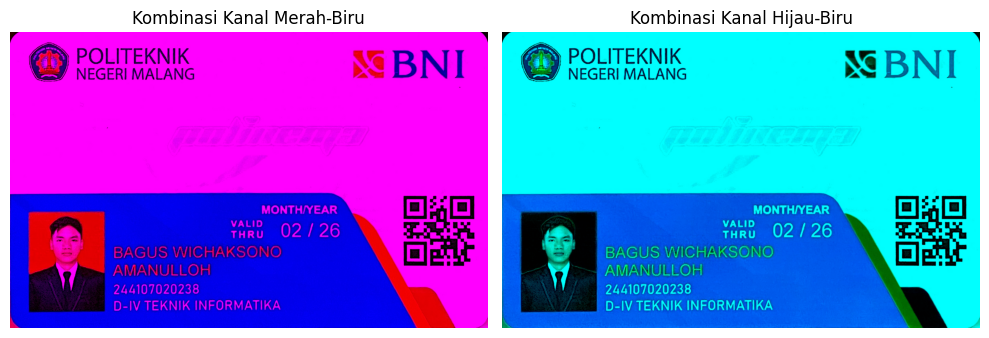

In [18]:
import cv2 as cv
import matplotlib.pyplot as plt

# Membaca gambar KTM dan konversi BGR ke RGB
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_ktm = cv.imread(path_ktm)
img_rgb = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

# 1. Kombinasi Kanal Merah-Biru (Kanal Hijau / Indeks 1 dinolkan)
img_red_blue = img_rgb.copy()
img_red_blue[:, :, 1] = 0

# 2. Kombinasi Kanal Hijau-Biru (Kanal Merah / Indeks 0 dinolkan)
img_green_blue = img_rgb.copy()
img_green_blue[:, :, 0] = 0

# Visualisasi Berdampingan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_red_blue)
plt.title('Kombinasi Kanal Merah-Biru')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_green_blue)
plt.title('Kombinasi Kanal Hijau-Biru')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tugas Penerapan 2: Pencerminan Citra (Flip Vertikal, Horizontal, dan Both)

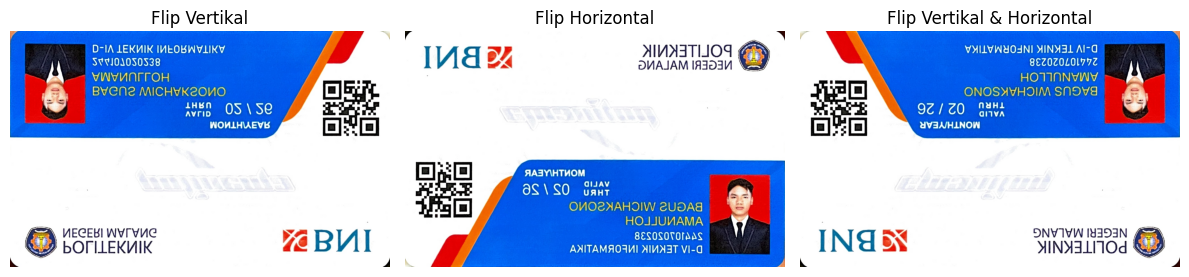

In [19]:
import cv2 as cv
import matplotlib.pyplot as plt

# Membaca gambar KTM dan konversi BGR ke RGB
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_ktm = cv.imread(path_ktm)
img_rgb = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

# Operasi Flipping
flip_vert = cv.flip(img_rgb, 0)   # Vertikal (flipCode = 0)
flip_horiz = cv.flip(img_rgb, 1)  # Horizontal (flipCode = 1)
flip_both = cv.flip(img_rgb, -1)  # Keduanya (flipCode = -1)

# Visualisasi 3 Subplot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(flip_vert)
plt.title('Flip Vertikal')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(flip_horiz)
plt.title('Flip Horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_both)
plt.title('Flip Vertikal & Horizontal')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tugas Penerapan 3: Anotasi Geometri dan Teks Nama pada Foto Aktivitas

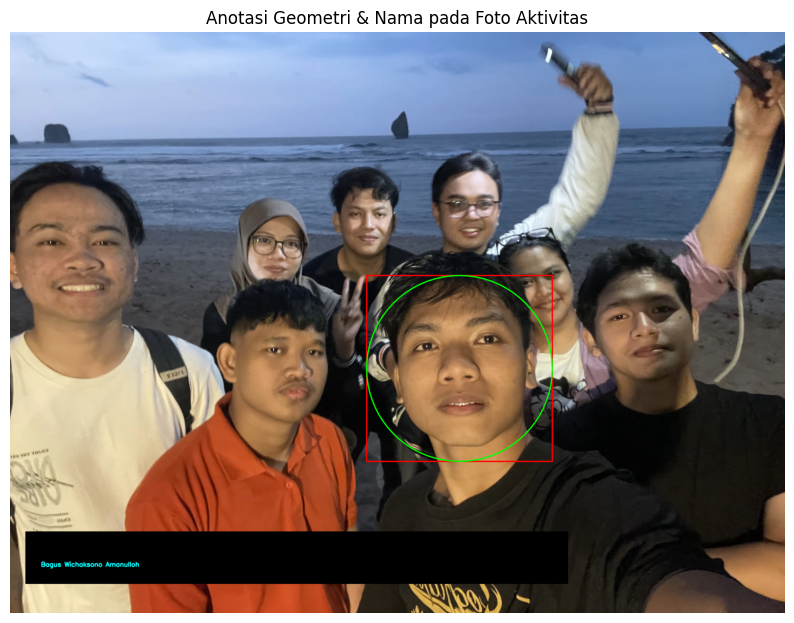

In [22]:
import os
import cv2 as cv
import matplotlib.pyplot as plt

path_aktivitas = '/content/drive/MyDrive/PCVK/foto_aktivitas.jpg'
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'

if os.path.exists(path_aktivitas):
  foto_act = cv.imread(path_aktivitas)
  foto_act_rgb = cv.cvtColor(foto_act, cv.COLOR_BGR2RGB)
else:
  foto_act = cv.imread(path_ktm)
  foto_act_rgb = cv.cvtColor(foto_act, cv.COLOR_BGR2RGB)

h, w, _ = foto_act_rgb.shape

# 1. Koordinat Presisi Wajah Kamu (Tengah-Bawah)
x_c, y_c = int(w * 0.58), int(h * 0.58)
r = int(h * 0.16)

# Menggambar Rectangle Merah & Circle Hijau tepat di Wajah Kamu
cv.rectangle(
    foto_act_rgb, (x_c - r, y_c - r), (x_c + r, y_c + r), (255, 0, 0), 5
)
cv.circle(foto_act_rgb, (x_c, y_c), r, (0, 255, 0), 5)

# 2. Menambahkan Teks Nama dengan Bar Background Hitam agar Terbaca Jelas
font = cv.FONT_HERSHEY_SIMPLEX
text = 'Bagus Wichaksono Amanulloh'

# Bar latar belakang hitam di bagian bawah
cv.rectangle(
    foto_act_rgb,
    (int(w * 0.02), int(h * 0.86)),
    (int(w * 0.72), int(h * 0.95)),
    (0, 0, 0),
    -1,
)

# Teks Nama Warna Cyan/Kuning
cv.putText(
    foto_act_rgb,
    text,
    (int(w * 0.04), int(h * 0.92)),
    font,
    1.1,
    (0, 255, 255),
    3,
    cv.LINE_AA,
)

# Visualisasi Hasil
plt.figure(figsize=(10, 8))
plt.imshow(foto_act_rgb)
plt.title('Anotasi Geometri & Nama pada Foto Aktivitas')
plt.axis('off')
plt.show()

### **TUGAS PRAKTIKUM — Analisa**

**1. Rumusan Pertanyaan**:
"Apakah proses *downscaling* (memperkecil ukuran citra) yang diikuti dengan *upscaling* (memperbesar kembali ke ukuran semula) akan mengubah nilai rata-rata intensitas piksel pada citra keabuan?"

**2. Rancangan Program**:
* Membaca citra `KTM.jpg` dan mengubahnya ke format keabuan (grayscale).
* Menghitung nilai rata-rata intensitas piksel awal ($\mu_1$).
* Memperkecil citra sebesar 50% dari dimensi asli menggunakan interpolasi `cv.INTER_AREA`.
* Memperbesar kembali citra tersebut ke ukuran semula menggunakan interpolasi `cv.INTER_LINEAR`.
* Menghitung nilai rata-rata intensitas piksel citra hasil rekonstruksi ($\mu_2$) serta selisih mutlaknya dengan nilai awal.

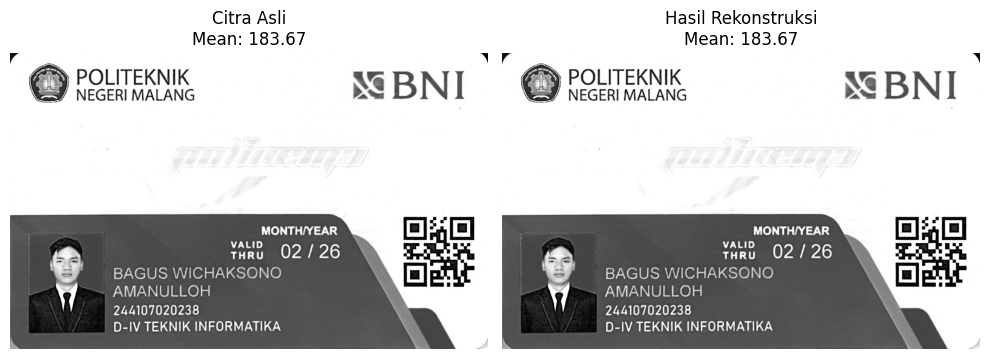

Rata-rata Intensitas Asli         : 183.6651
Rata-rata Intensitas Rekonstruksi: 183.6651
Selisih Rata-rata Intensitas     : 0.0000


In [23]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Membaca citra dan konversi ke Grayscale
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_ktm = cv.imread(path_ktm)
img_gray = cv.cvtColor(img_ktm, cv.COLOR_BGR2GRAY)

h, w = img_gray.shape

# 2. Menhitung rata-rata intensitas awal
mean_original = img_gray.mean()

# 3. Downscaling (50%) lalu Upscaling (kembali ke 100%)
img_small = cv.resize(
    img_gray, (w // 2, h // 2), interpolation=cv.INTER_AREA
)
img_restored = cv.resize(
    img_gray, (w, h), interpolation=cv.INTER_LINEAR
)

# 4. Menghitung rata-rata intensitas rekonstruksi
mean_restored = img_restored.mean()
diff_mean = abs(mean_original - mean_restored)

# 5. Visualisasi Hasil
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title(f'Citra Asli\nMean: {mean_original:.2f}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_restored, cmap='gray')
plt.title(f'Hasil Rekonstruksi\nMean: {mean_restored:.2f}')
plt.axis('off')

plt.tight_layout()
plt.show()

# Print data hasil analisa
print(f'Rata-rata Intensitas Asli         : {mean_original:.4f}')
print(f'Rata-rata Intensitas Rekonstruksi: {mean_restored:.4f}')
print(f'Selisih Rata-rata Intensitas     : {diff_mean:.4f}')

**3. Kesimpulan Analisa**:
Proses *downscaling* yang dilanjutkan dengan *upscaling* **tidak mengubah rata-rata intensitas piksel secara signifikan** (selisih mendekati 0), karena algoritma interpolasi merata-ratakan nilai piksel tetangga. Meskipun nilai rata-rata intensitasnya tetap terjaga, detail frekuensi tinggi (seperti ketajaman tepi dan garis teks halus) tetap mengalami kehilangan informasi (*blurring*) akibat reduksi piksel pada tahap *downscaling*.

### **TUGAS PRAKTIKUM — Aplikasi (Studi Kasus 1: Label Identitas Adaptif)**

**Deskripsi Kasus**:
Sistem pembubuhan label identitas adaptif pada foto dokumentasi dengan berbagai ukuran resolusi. Tinggi bar dan ukuran font dihitung secara rasional berdasarkan dimensi tinggi gambar (`h`), sehingga proporsi tampilan tetap seimbang di segala resolusi.

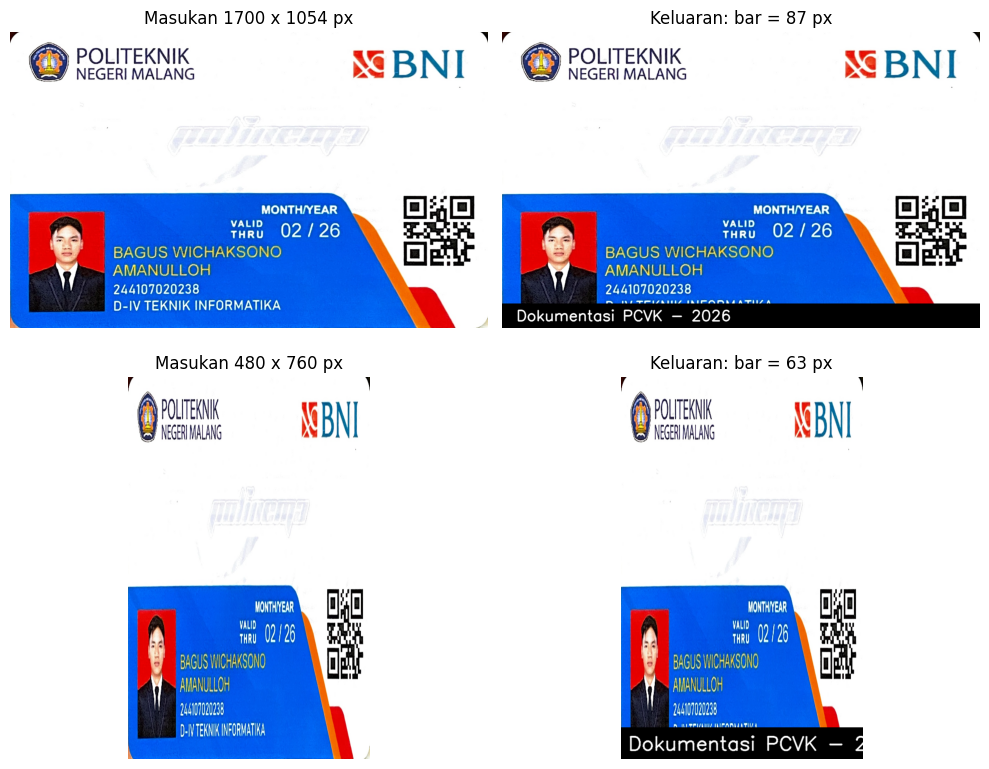

In [24]:
import cv2 as cv
import matplotlib.pyplot as plt


def apply_adaptive_label(img_rgb, text='Dokumentasi PCVK - 2026'):
  img_out = img_rgb.copy()
  h, w, _ = img_out.shape

  # Perhitungan adaptif berdasarkan tinggi gambar (h)
  bar_h = h // 12
  font_scale = h / 600.0
  thickness = max(1, int(h / 300))

  # Menambahkan bar hitam di bagian bawah
  img_out[-bar_h:, :, :] = [0, 0, 0]

  # Menambahkan teks putih di dalam bar
  font = cv.FONT_HERSHEY_SIMPLEX
  cv.putText(
      img_out,
      text,
      (int(w * 0.03), h - int(bar_h * 0.3)),
      font,
      font_scale,
      (255, 255, 255),
      thickness,
      cv.LINE_AA,
  )

  return img_out, bar_h


# Simulasi 2 gambar beda ukuran (Landscape & Portrait)
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_land = cv.imread(path_ktm)
img_land_rgb = cv.cvtColor(img_land, cv.COLOR_BGR2RGB)

# Membuat gambar versi Portrait (480 x 760 px)
img_port_rgb = cv.resize(img_land_rgb, (480, 760))

# Menerapkan fungsi adaptif
res_land, bar1 = apply_adaptive_label(img_land_rgb)
res_port, bar2 = apply_adaptive_label(img_port_rgb)

# Visualisasi Hasil
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_land_rgb)
plt.title(f'Masukan {img_land_rgb.shape[1]} x {img_land_rgb.shape[0]} px')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(res_land)
plt.title(f'Keluaran: bar = {bar1} px')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_port_rgb)
plt.title(f'Masukan {img_port_rgb.shape[1]} x {img_port_rgb.shape[0]} px')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(res_port)
plt.title(f'Keluaran: bar = {bar2} px')
plt.axis('off')

plt.tight_layout()
plt.show()

### **TUGAS PRAKTIKUM — Aplikasi (Studi Kasus 2: Thumbnail 1:1 Lapak Daring)**

**Deskripsi Kasus**:
Sistem pembuat thumbnail produk berasio 1:1 tanpa memotong (*crop*) atau merusak rasio asli gambar. Sisa ruang otomatis diisi kanvas putih, gambar ditempatkan tepat di tengah, dan diberi logo/nama toko proporsional di sudut atas.

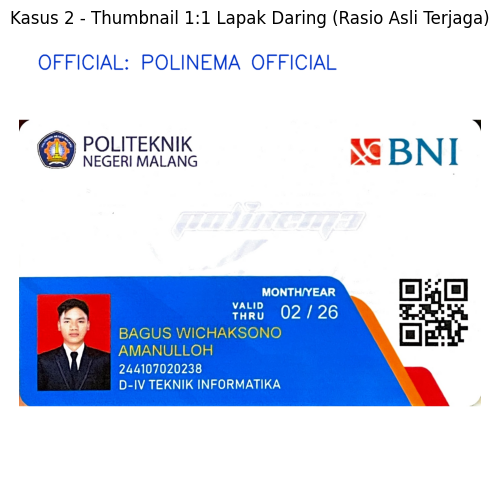

In [25]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


def create_square_thumbnail(
    img_rgb, shop_name='INFORMATIKA STORE', bg_color=(255, 255, 255)
):
  h, w, _ = img_rgb.shape
  max_dim = max(h, w)

  # Membuat kanvas persegi 1:1 dengan warna latar
  canvas = np.full((max_dim, max_dim, 3), bg_color, dtype=np.uint8)

  # Menghitung offset posisi tengah (centering)
  y_offset = (max_dim - h) // 2
  x_offset = (max_dim - w) // 2

  # Menempelkan gambar di tengah kanvas
  canvas[y_offset : y_offset + h, x_offset : x_offset + w] = img_rgb

  # Menambahkan nama/logo toko adaptif
  font_scale = max_dim / 700.0
  thickness = max(1, int(max_dim / 350))

  cv.putText(
      canvas,
      f'OFFICIAL: {shop_name}',
      (int(max_dim * 0.04), int(max_dim * 0.08)),
      cv.FONT_HERSHEY_SIMPLEX,
      font_scale,
      (0, 50, 200),
      thickness,
      cv.LINE_AA,
  )

  return canvas


# Pengujian dengan gambar KTM
path_ktm = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_ktm = cv.imread(path_ktm)
img_rgb = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

# Membuat thumbnail 1:1
thumbnail = create_square_thumbnail(img_rgb, shop_name='POLINEMA OFFICIAL')

# Visualisasi Hasil
plt.figure(figsize=(6, 6))
plt.imshow(thumbnail)
plt.title('Kasus 2 - Thumbnail 1:1 Lapak Daring (Rasio Asli Terjaga)')
plt.axis('off')
plt.show()